# Heart Disease Dataset Inspection

This notebook performs an initial inspection of the Cleveland Heart Disease
dataset selected for the Healytics project.

The inspection focuses on:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Duplicate records
- Descriptive statistics
- Target distribution
- Unique values in categorical/discrete features

No preprocessing or model training is performed in this notebook.

## 1. Import Libraries

In [32]:
import pandas as pd
import numpy as np

## 2. Overview of Dataset

In [33]:
with open(
    "../../data/raw/cleveland.data",
    "r",
    encoding="latin1"
) as file:
    lines = file.readlines()

print("Number of lines:", len(lines))

print("\nFirst 10 lines:")
for line in lines[:10]:
    print(line.rstrip())

Number of lines: 303

First 10 lines:
63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


## 2.1. Parse the Raw Cleveland Dataset

The original Cleveland file is stored in a raw multi-line format.
Each patient record contains 76 attributes, while Healytics will use
the standard 14-attribute modeling subset documented by UCI:

- age
- sex
- cp
- trestbps
- chol
- fbs
- restecg
- thalach
- exang
- oldpeak
- slope
- ca
- thal
- num

The `num` attribute is the heart-disease target.

In [34]:
# Read the complete raw file
with open(
    "../../data/raw/cleveland.data",
    "r",
    encoding="latin1"
) as file:
    raw_text = file.read()

# Split all whitespace-separated values
values = raw_text.split()

print("Total raw values:", len(values))
print("First 30 values:")
print(values[:30])

Total raw values: 303
First 30 values:
['63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0', '67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2', '67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1', '37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0', '41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0', '56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0', '62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3', '57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0', '63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2', '53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1', '57.0,1.0,4.0,140.0,192.0,0.0,0.0,148.0,0.0,0.4,2.0,0.0,6.0,0', '56.0,0.0,2.0,140.0,294.0,0.0,2.0,153.0,0.0,1.3,2.0,0.0,3.0,0', '56.0,1.0,3.0,130.0,256.0,1.0,2.0,142.0,1.0,0.6,2.0,1.0,6.0,2', '44.0,1.0,2.0,120.0,263.0,0.0,0.0,173.0,0.0,0.0,1.0,0.0,7.0,0', '52.0,1.0,3.0,172.0,199.0,1.0,0.0,162.0,0.0,0.5,1.0,0.0,7.0,0', 

In [35]:
# Count record-ending markers
name_count = values.count("name")

print("Number of 'name' markers:", name_count)

# Show positions of the first few record endings
name_positions = [i for i, value in enumerate(values) if value == "name"]

print("\nFirst 5 'name' positions:")
print(name_positions[:5])

print("\nLast 5 'name' positions:")
print(name_positions[-5:])

Number of 'name' markers: 0

First 5 'name' positions:
[]

Last 5 'name' positions:
[]


In [36]:
# Find the boundaries of each record using "name"
record_lengths = []

start = 0

for i, value in enumerate(values):
    if value == "name":
        record_length = i - start + 1
        record_lengths.append(record_length)
        start = i + 1

print("Total records detected:", len(record_lengths))

print("\nUnique record lengths:")
print(sorted(set(record_lengths)))

print("\nRecord length frequencies:")
from collections import Counter
print(Counter(record_lengths))

Total records detected: 0

Unique record lengths:
[]

Record length frequencies:
Counter()


In [37]:
with open(
    "../../data/raw/cleveland.data",
    "r",
    encoding="latin1"
) as file:
    raw_text = file.read()

values = raw_text.split()

print("Total raw values:", len(values))

name_count = values.count("name")
print("Number of 'name' markers:", name_count)

print("Expected records:", 303)
print("Expected values:", 303 * 76)
print("Values divisible by 76:", len(values) % 76 == 0)

Total raw values: 303
Number of 'name' markers: 0
Expected records: 303
Expected values: 23028
Values divisible by 76: False


In [38]:
import pandas as pd

heart_columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "num"
]

heart_df = pd.read_csv(
    "../../data/raw/cleveland.data",
    header=None,
    names=heart_columns
)

print("Shape:", heart_df.shape)

print("\nFirst 5 rows:")
display(heart_df.head())

print("\nData types:")
print(heart_df.dtypes)

Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca              str
thal            str
num           int64
dtype: object


## 2.2 Missing Values, Duplicates and Target Inspection

The Cleveland heart disease dataset contains 303 patient records and
13 input features with one target variable (`num`).

Before preprocessing, we inspect:

- Missing values and their representation
- Duplicate records
- Target value distribution
- Unique values of categorical/discrete features

No missing values or categorical values will be modified at this stage.
The purpose of this section is only to understand the raw processed dataset.

In [39]:
# Missing values
print("Missing values:")
print(heart_df.isnull().sum())

print("\n" + "=" * 60)

# Check for '?' values
print("Question-mark values:")
for column in heart_df.columns:
    count = (heart_df[column] == "?").sum()
    if count > 0:
        print(f"{column}: {count}")

print("\n" + "=" * 60)

# Duplicate rows
print("Duplicate rows:", heart_df.duplicated().sum())

print("\n" + "=" * 60)

# Target distribution
print("Target (`num`) distribution:")
print(heart_df["num"].value_counts().sort_index())

print("\nTarget percentages:")
print(
    (heart_df["num"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

print("\n" + "=" * 60)

# Unique values of discrete/categorical features
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

print("Unique values:")
for column in categorical_features:
    print(f"{column}: {heart_df[column].unique()}")

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Question-mark values:
ca: 4
thal: 2

Duplicate rows: 0

Target (`num`) distribution:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Target percentages:
num
0    54.13
1    18.15
2    11.88
3    11.55
4     4.29
Name: proportion, dtype: float64

Unique values:
sex: [1. 0.]
cp: [1. 4. 3. 2.]
fbs: [1. 0.]
restecg: [2. 0. 1.]
exang: [0. 1.]
slope: [3. 2. 1.]
ca: <ArrowStringArray>
['0.0', '3.0', '2.0', '1.0', '?']
Length: 5, dtype: str
thal: <ArrowStringArray>
['6.0', '3.0', '7.0', '?']
Length: 4, dtype: str


In [40]:
# Target distribution
print("TARGET DISTRIBUTION")
print("=" * 50)

print("Unique target values:")
print(heart_df["num"].unique())

print("\nTarget counts:")
print(heart_df["num"].value_counts().sort_index())

print("\nTarget percentages:")
target_percent = (
    heart_df["num"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print(target_percent.round(2))


# Categorical / discrete feature values
print("\n" + "=" * 50)
print("CATEGORICAL / DISCRETE FEATURE VALUES")
print("=" * 50)

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

for column in categorical_features:
    print(f"\n{column}:")
    print(heart_df[column].value_counts(dropna=False).sort_index())

TARGET DISTRIBUTION
Unique target values:
[0 2 1 3 4]

Target counts:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Target percentages:
num
0    54.13
1    18.15
2    11.88
3    11.55
4     4.29
Name: proportion, dtype: float64

CATEGORICAL / DISCRETE FEATURE VALUES

sex:
sex
0.0     97
1.0    206
Name: count, dtype: int64

cp:
cp
1.0     23
2.0     50
3.0     86
4.0    144
Name: count, dtype: int64

fbs:
fbs
0.0    258
1.0     45
Name: count, dtype: int64

restecg:
restecg
0.0    151
1.0      4
2.0    148
Name: count, dtype: int64

exang:
exang
0.0    204
1.0     99
Name: count, dtype: int64

slope:
slope
1.0    142
2.0    140
3.0     21
Name: count, dtype: int64

ca:
ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

thal:
thal
3.0    166
6.0     18
7.0    117
?        2
Name: count, dtype: int64


In [41]:
print("CATEGORICAL FEATURE SUMMARY")
print("=" * 60)

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

for column in categorical_features:
    print(f"\n{column}")
    print("-" * 30)
    print(heart_df[column].value_counts(dropna=False).sort_index())

CATEGORICAL FEATURE SUMMARY

sex
------------------------------
sex
0.0     97
1.0    206
Name: count, dtype: int64

cp
------------------------------
cp
1.0     23
2.0     50
3.0     86
4.0    144
Name: count, dtype: int64

fbs
------------------------------
fbs
0.0    258
1.0     45
Name: count, dtype: int64

restecg
------------------------------
restecg
0.0    151
1.0      4
2.0    148
Name: count, dtype: int64

exang
------------------------------
exang
0.0    204
1.0     99
Name: count, dtype: int64

slope
------------------------------
slope
1.0    142
2.0    140
3.0     21
Name: count, dtype: int64

ca
------------------------------
ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

thal
------------------------------
thal
3.0    166
6.0     18
7.0    117
?        2
Name: count, dtype: int64


In [42]:
remaining_features = [
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

print("REMAINING CATEGORICAL FEATURES")
print("=" * 60)

for column in remaining_features:
    print(f"\n{column}")
    print("-" * 30)
    print(heart_df[column].value_counts(dropna=False).sort_index())

REMAINING CATEGORICAL FEATURES

restecg
------------------------------
restecg
0.0    151
1.0      4
2.0    148
Name: count, dtype: int64

exang
------------------------------
exang
0.0    204
1.0     99
Name: count, dtype: int64

slope
------------------------------
slope
1.0    142
2.0    140
3.0     21
Name: count, dtype: int64

ca
------------------------------
ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

thal
------------------------------
thal
3.0    166
6.0     18
7.0    117
?        2
Name: count, dtype: int64


In [43]:
print("ca")
print("-" * 30)
print(heart_df["ca"].value_counts(dropna=False).sort_index())

print("\nthal")
print("-" * 30)
print(heart_df["thal"].value_counts(dropna=False).sort_index())

ca
------------------------------
ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

thal
------------------------------
thal
3.0    166
6.0     18
7.0    117
?        2
Name: count, dtype: int64


## 2.3 Numerical Feature Statistics

The numerical features are inspected to understand their central tendency,
spread, minimum and maximum values before preprocessing.

This step helps identify:

- Feature ranges
- Potentially unusual values
- Differences in scale between features
- Features that may require scaling during model development

No values are modified during this inspection.

In [44]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

print("NUMERICAL FEATURE SUMMARY")
print("=" * 70)

display(
    heart_df[numerical_features]
    .describe()
    .T
    .round(2)
)

NUMERICAL FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.44,9.04,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.69,51.78,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.61,22.88,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.04,1.16,0.0,0.0,0.8,1.6,6.2


In [45]:
print("FEATURE RANGES")
print("=" * 50)

for column in numerical_features:
    print(
        f"{column:10s} : "
        f"min = {heart_df[column].min():.2f}, "
        f"max = {heart_df[column].max():.2f}"
    )

FEATURE RANGES
age        : min = 29.00, max = 77.00
trestbps   : min = 94.00, max = 200.00
chol       : min = 126.00, max = 564.00
thalach    : min = 71.00, max = 202.00
oldpeak    : min = 0.00, max = 6.20


## 2.4 Exploratory Data Analysis

Visual exploratory analysis is performed to understand:

- Target class distribution
- Numerical feature distributions
- Categorical feature distributions
- Relationships between numerical features
- Potential patterns associated with the target

The visualizations are exploratory and are not used to make causal
or clinical conclusions.

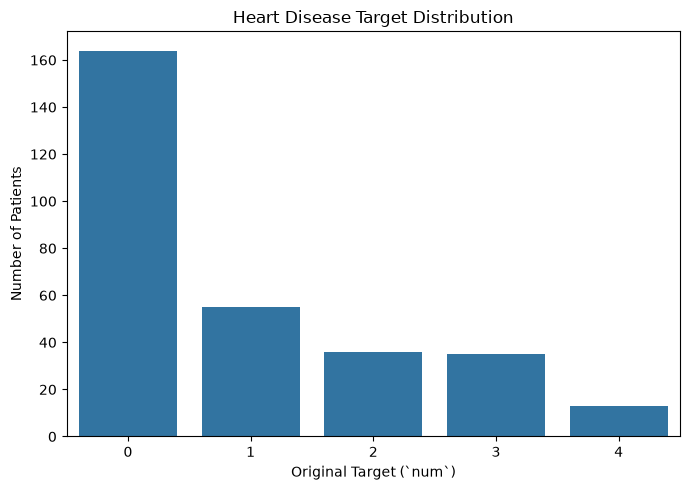

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=heart_df,
    x="num"
)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Original Target (`num`)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

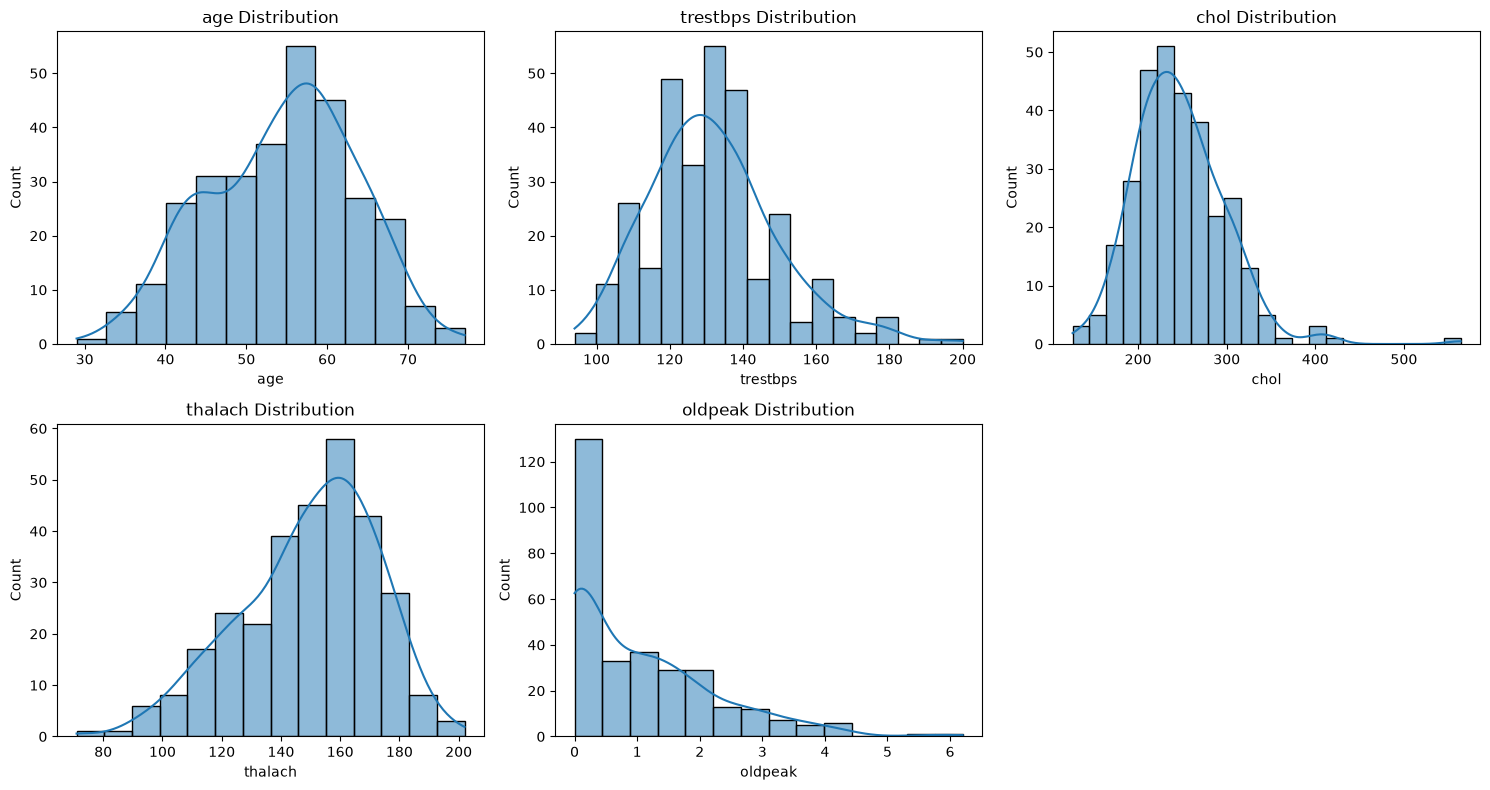

In [47]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8)
)

for ax, column in zip(
    axes.flatten(),
    numerical_features
):
    sns.histplot(
        data=heart_df,
        x=column,
        kde=True,
        ax=ax
    )
    
    ax.set_title(f"{column} Distribution")

# Hide unused subplot
axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()

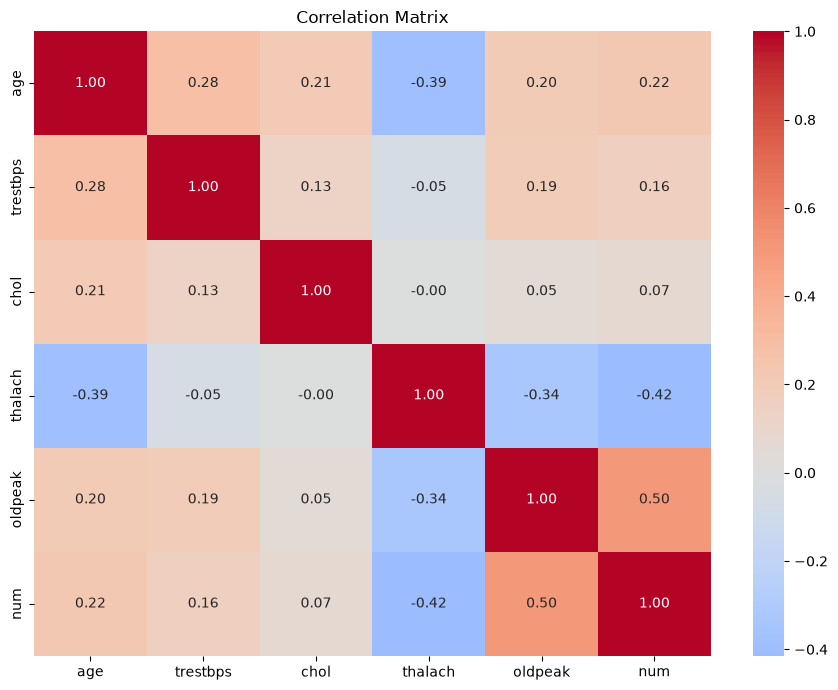

In [48]:
correlation_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "num"
]

correlation_matrix = heart_df[
    correlation_features
].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

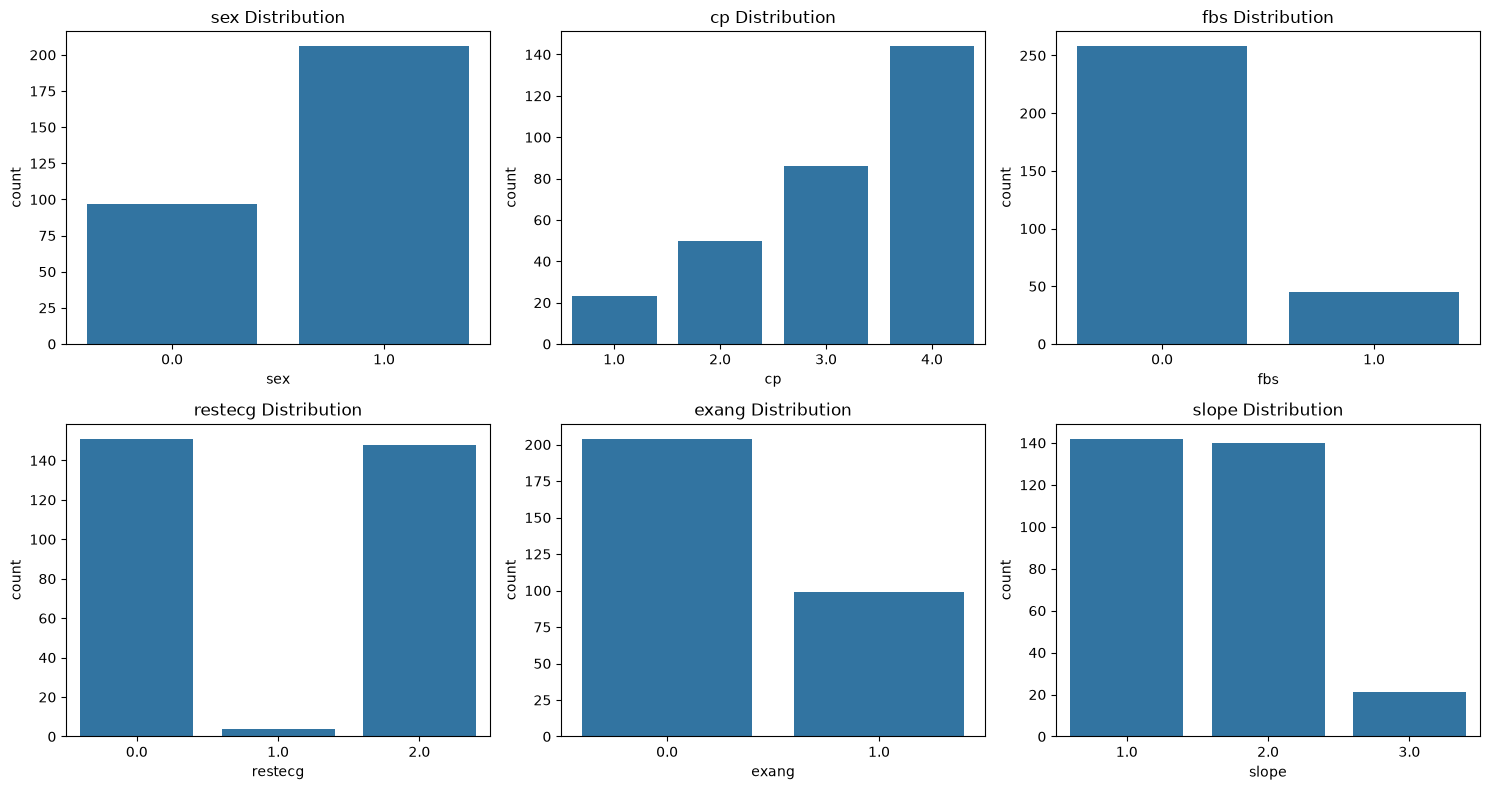

In [49]:
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope"
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8)
)

for ax, column in zip(
    axes.flatten(),
    categorical_features
):
    sns.countplot(
        data=heart_df,
        x=column,
        ax=ax
    )
    
    ax.set_title(f"{column} Distribution")

plt.tight_layout()
plt.show()

## 2.5 Inspection Summary

The Heart Disease dataset contains 303 patient records and 13 input
features with the original `num` target.

Key observations from inspection:

- The original target contains five values: 0, 1, 2, 3 and 4.
- For the planned binary classification task, `num = 0` represents
  absence of heart disease and `num > 0` represents presence.
- There are no duplicate rows.
- Missing values are represented by `?` in `ca` and `thal`.
- `ca` contains 4 missing values and `thal` contains 2 missing values.
- Numerical features have different value ranges.
- Categorical/discrete features contain a mixture of binary and
  multi-category variables.
- No values are modified during this inspection stage.

The observations from this notebook will guide the preprocessing
pipeline developed in the next milestone.

## 2.6 Outlier Analysis

Boxplots are used to identify potentially unusual observations in
numerical features.

The presence of an outlier does not automatically indicate an error.
Observations will therefore not be removed during EDA. Any preprocessing
decision regarding extreme values will be made separately and justified
during the preprocessing stage.

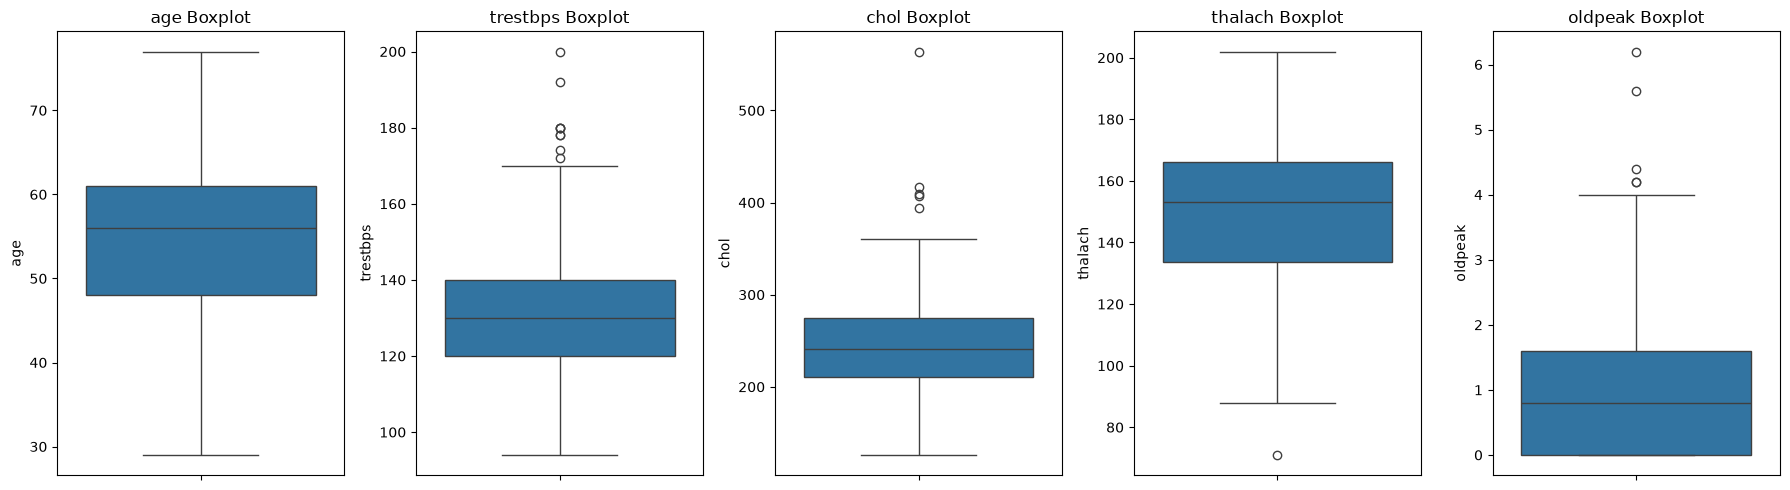

In [50]:
outlier_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

fig, axes = plt.subplots(
    1,
    len(outlier_features),
    figsize=(18, 5)
)

for ax, column in zip(axes, outlier_features):
    sns.boxplot(
        y=heart_df[column],
        ax=ax
    )
    ax.set_title(f"{column} Boxplot")
    ax.set_ylabel(column)

plt.tight_layout()
plt.show()

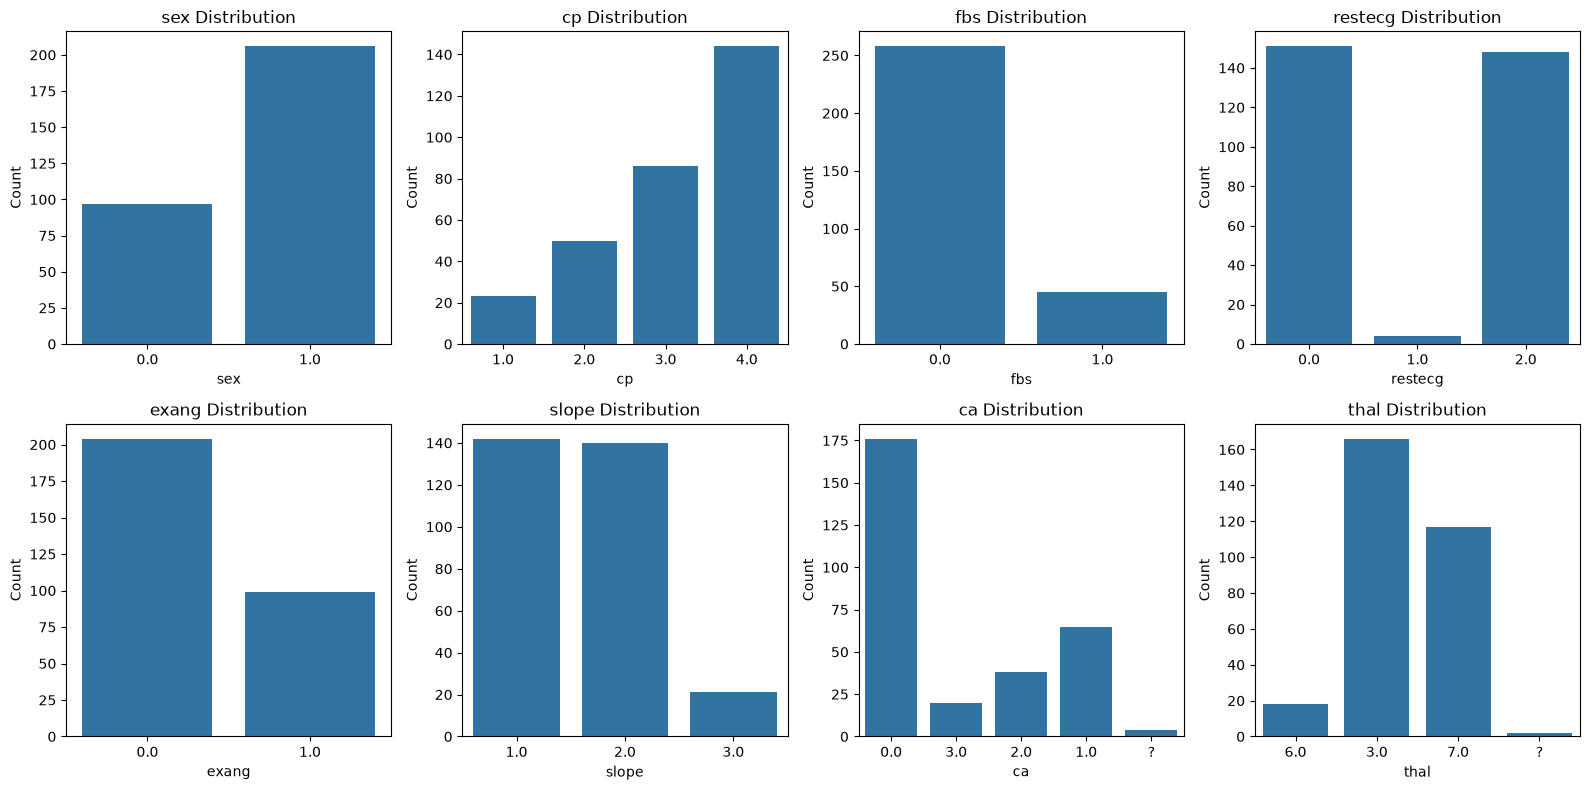

In [51]:
eda_categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

for ax, column in zip(
    axes.flatten(),
    eda_categorical_features
):
    sns.countplot(
        data=heart_df,
        x=column,
        ax=ax
    )
    
    ax.set_title(f"{column} Distribution")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [52]:
# Create a binary target only for exploratory analysis
heart_df["target_binary"] = (
    heart_df["num"] > 0
).astype(int)

print("Binary target distribution:")
print(heart_df["target_binary"].value_counts())

print("\nBinary target percentages:")
print(
    (
        heart_df["target_binary"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
)

Binary target distribution:
target_binary
0    164
1    139
Name: count, dtype: int64

Binary target percentages:
target_binary
0    54.13
1    45.87
Name: proportion, dtype: float64


## 2.7 Numerical Features vs Binary Target

Numerical features are compared across the two binary target groups:

- 0: No heart disease
- 1: Heart disease present

Boxplots are used to examine differences in the distributions.
These observations are exploratory and do not establish causation.

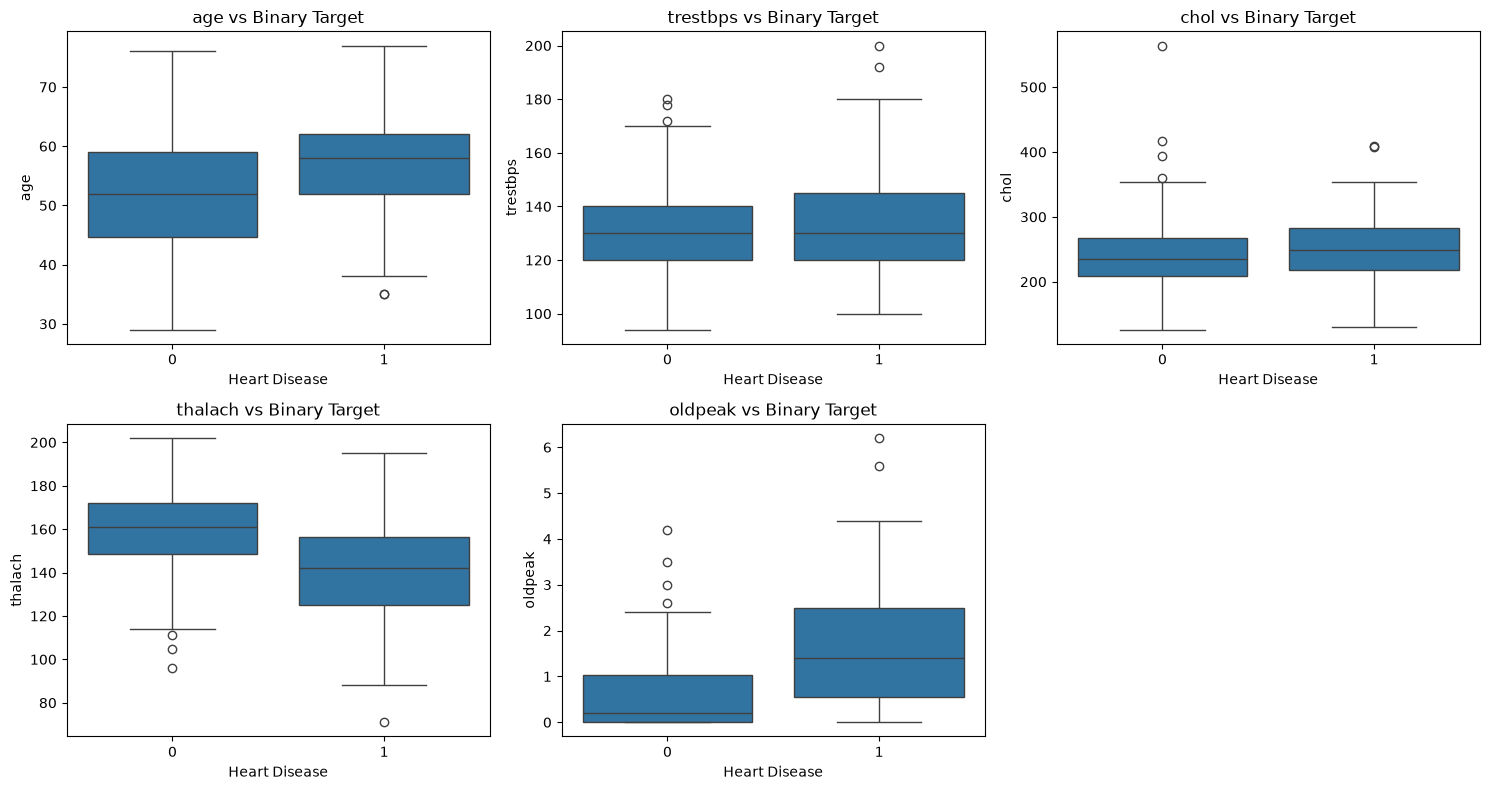

In [54]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

for ax, column in zip(
    axes.flatten(),
    numerical_features
):
    sns.boxplot(
        data=heart_df,
        x="target_binary",
        y=column,
        ax=ax
    )
    
    ax.set_title(f"{column} vs Binary Target")
    ax.set_xlabel("Heart Disease")
    ax.set_ylabel(column)

axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()

## 2.8 Categorical Features vs Binary Target

Categorical features are compared across the binary target groups.

Stacked proportions are more informative than raw counts because the
categories have different overall frequencies.

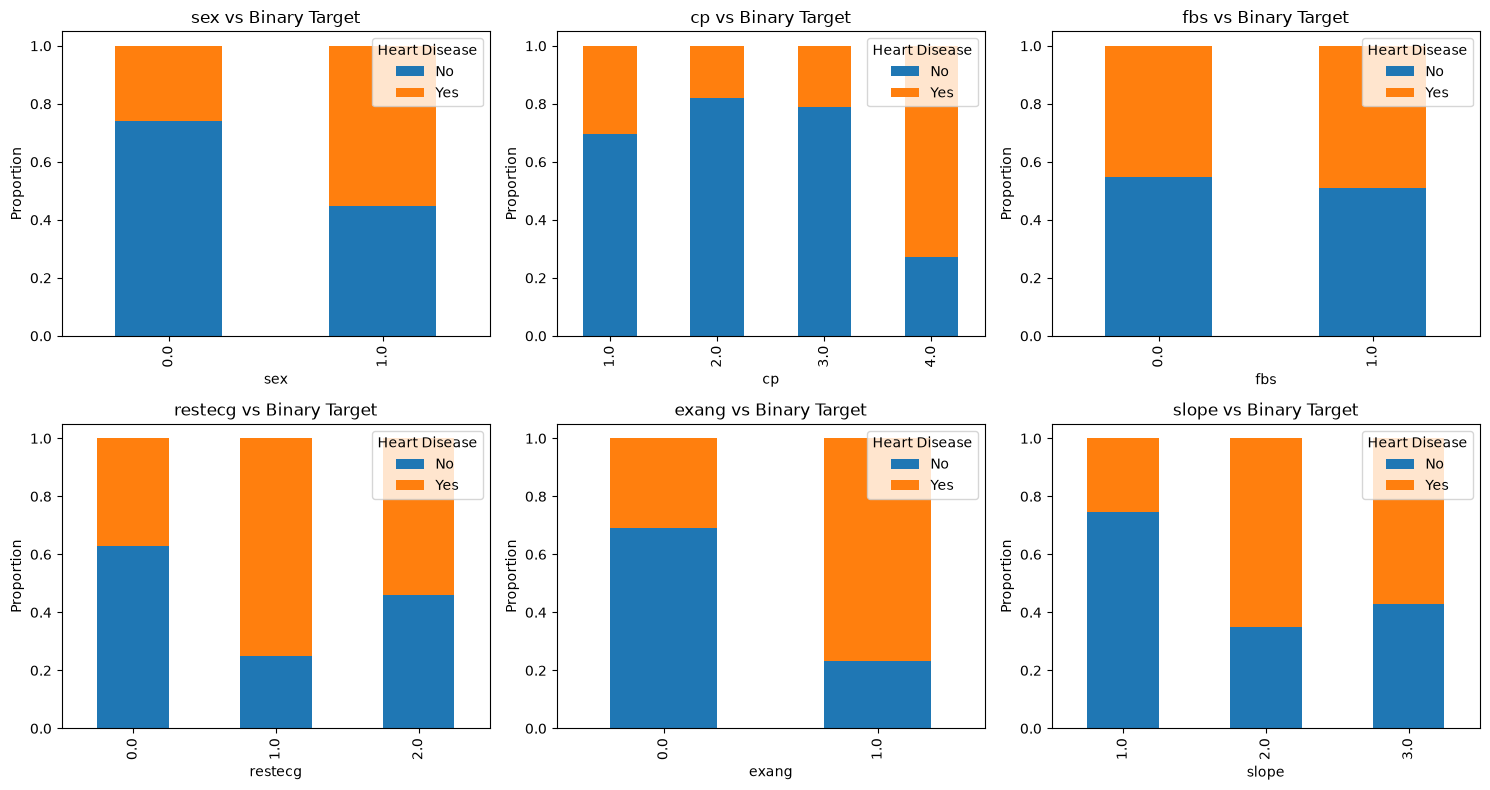

In [55]:
categorical_target_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

for ax, column in zip(
    axes.flatten(),
    categorical_target_features
):
    target_proportion = pd.crosstab(
        heart_df[column],
        heart_df["target_binary"],
        normalize="index"
    )
    
    target_proportion.plot(
        kind="bar",
        stacked=True,
        ax=ax
    )
    
    ax.set_title(f"{column} vs Binary Target")
    ax.set_xlabel(column)
    ax.set_ylabel("Proportion")
    ax.legend(
        title="Heart Disease",
        labels=["No", "Yes"]
    )

plt.tight_layout()
plt.show()

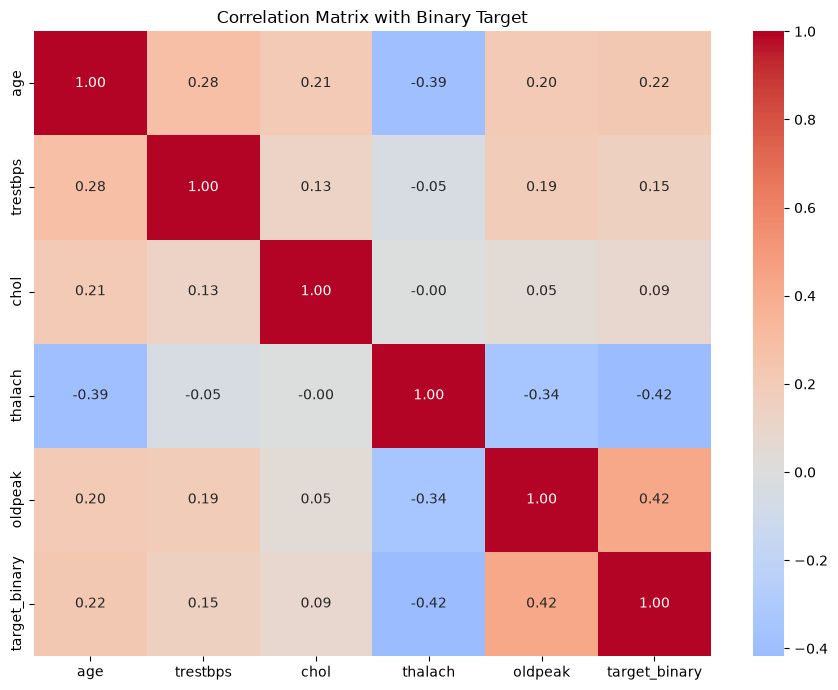

In [56]:
binary_correlation_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "target_binary"
]

binary_corr = heart_df[
    binary_correlation_features
].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    binary_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix with Binary Target")

plt.tight_layout()
plt.show()

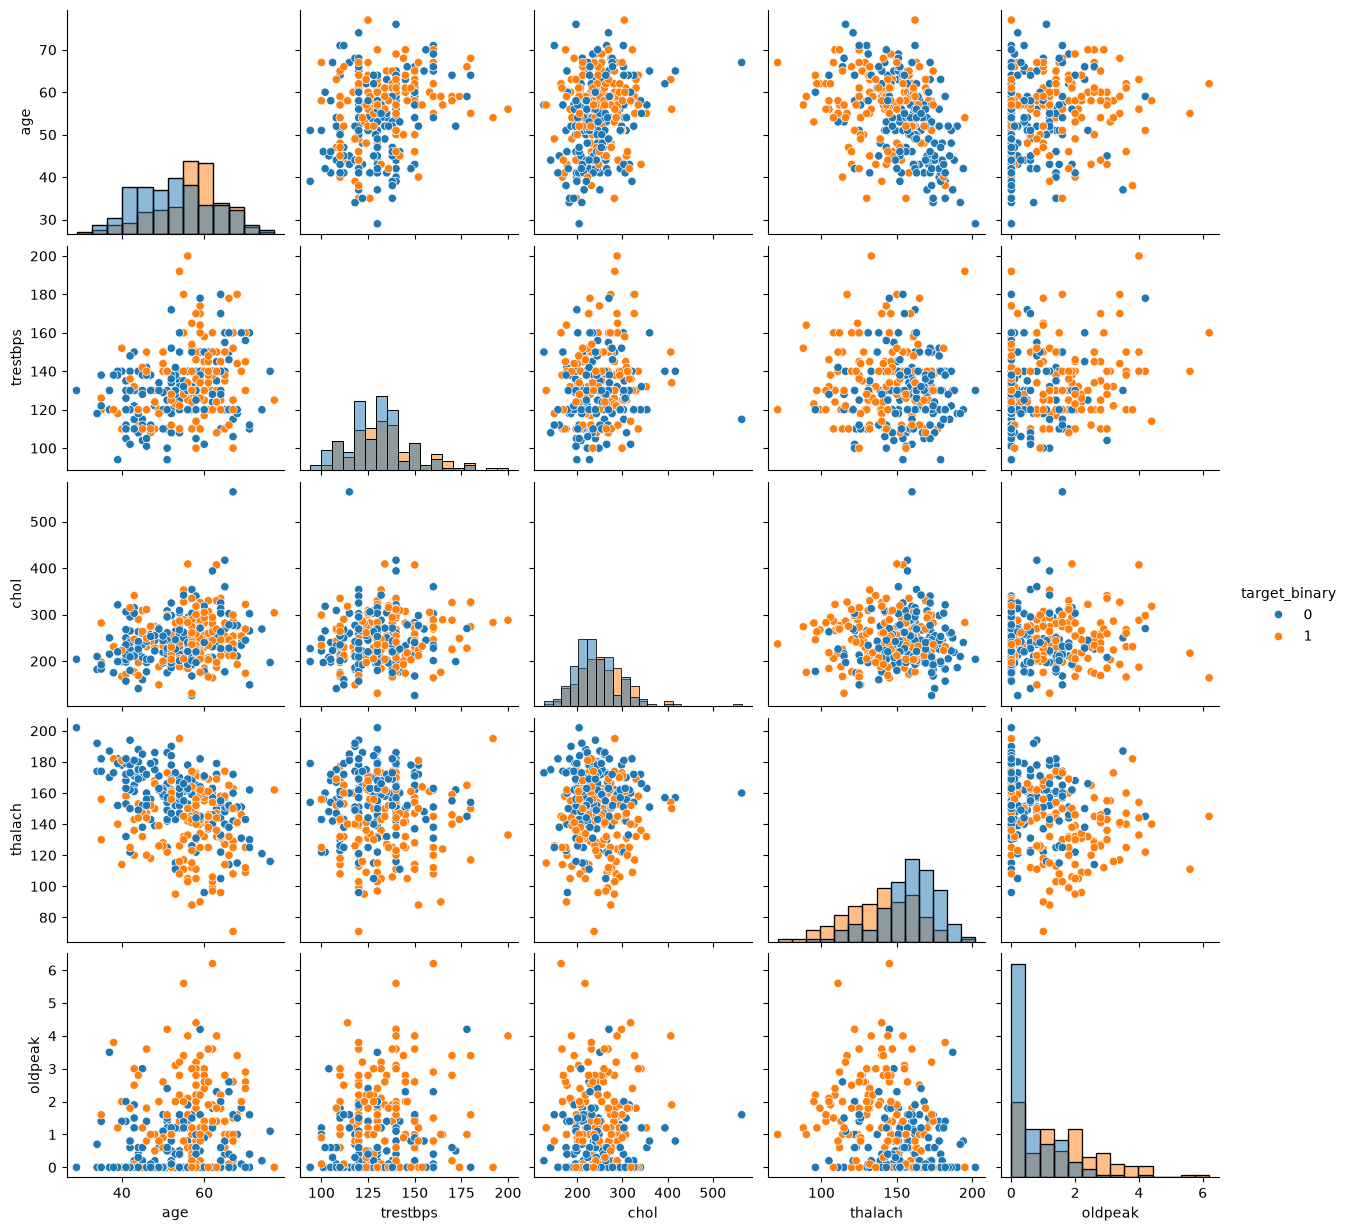

In [57]:
pairplot_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "target_binary"
]

sns.pairplot(
    heart_df[pairplot_features],
    hue="target_binary",
    diag_kind="hist"
)

plt.show()

## 2.9 `ca` and `thal` vs Binary Target

The `ca` and `thal` features contain missing values represented by `?`.
For exploratory analysis, these missing values are retained as a separate
category rather than being imputed.

This allows us to inspect the observed distribution without introducing
preprocessing decisions into the EDA stage.

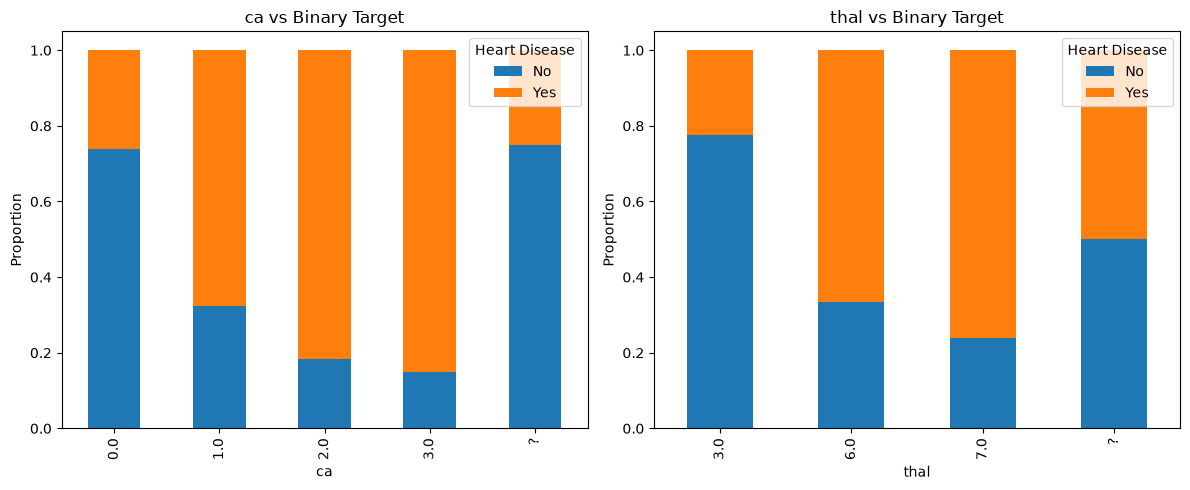

In [59]:
# Analyze ca and thal against the binary target

missing_categorical_features = ["ca", "thal"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

for ax, column in zip(
    axes,
    missing_categorical_features
):
    target_proportion = pd.crosstab(
        heart_df[column],
        heart_df["target_binary"],
        normalize="index"
    )

    target_proportion.plot(
        kind="bar",
        stacked=True,
        ax=ax
    )

    ax.set_title(f"{column} vs Binary Target")
    ax.set_xlabel(column)
    ax.set_ylabel("Proportion")
    ax.legend(
        title="Heart Disease",
        labels=["No", "Yes"]
    )

plt.tight_layout()
plt.show()

## 2.10 Numerical Features by Target Group

Summary statistics are calculated separately for patients in the two
binary target groups.

This provides a numerical complement to the boxplot analysis.

In [60]:
target_summary = (
    heart_df
    .groupby("target_binary")[numerical_features]
    .agg(["mean", "median", "std"])
    .round(2)
)

display(target_summary)

age              trestbps                  chol         \
                mean median   std     mean median    std    mean median   
target_binary                                                             
0              52.59   52.0  9.51   129.25  130.0  16.20  242.64  234.5   
1              56.63   58.0  7.94   134.57  130.0  18.77  251.47  249.0   

                     thalach               oldpeak               
                 std    mean median    std    mean median   std  
target_binary                                                    
0              53.46  158.38  161.0  19.20    0.59    0.2  0.78  
1              49.49  139.26  142.0  22.59    1.57    1.4  1.30

## 2.11 Missing-Value Pattern

The processed Cleveland dataset represents missing values using `?`.
Only `ca` and `thal` contain such values in the selected features.

The missing values are visualized here without performing imputation.

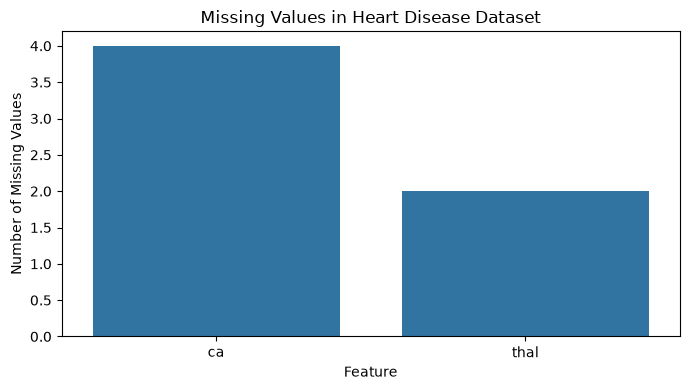

In [62]:
missing_counts = pd.Series({
    column: (heart_df[column] == "?").sum()
    for column in heart_df.columns
})

missing_counts = missing_counts[
    missing_counts > 0
]

plt.figure(figsize=(7, 4))

sns.barplot(
    x=missing_counts.index,
    y=missing_counts.values
)

plt.title("Missing Values in Heart Disease Dataset")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")

plt.tight_layout()
plt.show()

## 2.12 Outlier Summary

Potential outliers are identified using the 1.5 × IQR rule.

This analysis is descriptive only. An observation identified as an
outlier is not automatically considered erroneous and will not be
removed during the inspection stage.

In [63]:
outlier_summary = []

for column in numerical_features:
    q1 = heart_df[column].quantile(0.25)
    q3 = heart_df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (heart_df[column] < lower_bound) |
        (heart_df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": outlier_count
    })

outlier_df = pd.DataFrame(outlier_summary)

display(
    outlier_df.round(2)
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,age,48.0,61.0,13.0,28.50,80.50,0
1,trestbps,120.0,140.0,20.0,90.00,170.00,9
2,chol,211.0,275.0,64.0,115.00,371.00,5
3,thalach,133.5,166.0,32.5,84.75,214.75,1
4,oldpeak,0.0,1.6,1.6,-2.40,4.00,5


## 3. EDA Findings and Conclusions

### Dataset Structure

- The Cleveland Heart Disease dataset contains 303 observations.
- The dataset contains 13 input features and one original target variable,
  `num`.
- The original target contains five values: 0, 1, 2, 3 and 4.
- For the planned binary classification problem, `num = 0` represents
  the negative class and `num > 0` represents the positive class.

### Target Distribution

- The binary target contains 164 observations without disease (54.13%)
  and 139 observations with disease (45.87%).
- The binary classification target is therefore reasonably balanced.
- The original five-class target is more concentrated in class 0.

### Missing Values

- Missing values are represented by `?` rather than standard null values.
- `ca` contains 4 missing observations.
- `thal` contains 2 missing observations.
- Missing values will be handled during preprocessing rather than during
  EDA.

### Duplicate Records

- No duplicate rows were detected in the dataset.

### Numerical Features

- Numerical features have different ranges and scales.
- `oldpeak` is strongly right-skewed.
- `chol` and `trestbps` contain some higher-value observations.
- Boxplot analysis identifies potential outliers in several numerical
  features.
- Potential outliers will not be removed automatically because an
  outlier is not necessarily an erroneous observation.

### Numerical Features and Binary Target

Compared with the negative target group:

- The positive target group has a higher mean `age`.
- The positive target group has a higher mean `trestbps`.
- The difference in mean `chol` is relatively small.
- The positive target group has a lower mean `thalach`.
- The positive target group has a higher mean `oldpeak`.

These observations describe patterns in this dataset and do not establish
causal or clinical relationships.

### Correlation Analysis

The strongest numerical correlations with the binary target are:

- `oldpeak`: approximately +0.42
- `thalach`: approximately -0.42
- `age`: approximately +0.22
- `trestbps`: approximately +0.15
- `chol`: approximately +0.09

Correlation values describe linear association and should not be
interpreted as causal relationships.

### Categorical Features

- Several categorical features show different target proportions across
  their categories.
- Some categories have very small sample sizes, particularly `restecg=1`
  and the missing categories of `ca` and `thal`.
- These small groups should be interpreted cautiously.

### Preprocessing Implications

The EDA suggests that the preprocessing stage should:

1. Convert the `?` markers in `ca` and `thal` into missing values.
2. Handle missing values without data leakage.
3. Convert the original `num` target into a binary target.
4. Treat categorical variables appropriately during model preparation.
5. Consider feature scaling for models that are sensitive to feature scale.
6. Investigate the effect of potential outliers without automatically
   deleting observations.
7. Preserve the original dataset and perform transformations through a
   reproducible preprocessing pipeline.

In [64]:
# Remove EDA-only derived column
heart_df = heart_df.drop(columns=["target_binary"])

print("Final inspection dataset shape:", heart_df.shape)
print("Columns:")
print(heart_df.columns.tolist())

Final inspection dataset shape: (303, 14)
Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


## 4. End of Inspection and EDA

The inspection and exploratory data analysis of the Cleveland Heart
Disease dataset are complete.

No preprocessing transformations, imputation, scaling, encoding, outlier
removal, or target modification have been permanently applied in this
notebook.

The findings from this analysis will be used to design the reproducible
Heart Disease preprocessing pipeline in the next notebook.